# Toyota Stock Risk Analysis using GARCH & Value at Risk (VaR)

## Project Overview

This project explores the risk dynamics of Toyota stock using financial time series analysis and volatility modelling techniques.

The analysis begins by transforming price data into returns to enable statistical modelling. Volatility is examined to identify patterns such as volatility clustering, a common feature in financial markets. A GARCH(1,1) model is then implemented to estimate conditional volatility, capturing both the impact of market shocks and the persistence of risk over time.

To quantify downside risk, Value at Risk (VaR) is computed using both historical and model-based approaches. The project further extends the analysis by forecasting future volatility and VaR, providing a forward-looking perspective on market risk.

Overall, this project demonstrates how quantitative models can be used to measure, understand, and anticipate financial risk in a dynamic market environment.

## Objective
The objective of this project is to analyse the risk profile of Toyota stock by:
- Transforming price data into returns
- Measuring volatility and identifying clustering effects
- Modelling time-varying risk using a GARCH model
- Estimating downside risk using Value at Risk (VaR)
- Forecasting future market risk

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

##  Data Description

The dataset contains historical daily stock prices for Toyota.

Key variables:
- Date: Trading day
- Close Price: Daily closing price of the stock

This data is used to derive returns and analyse market risk over time.

In [2]:
df = pd.read_csv('Toyota_Stock_Prices_1980_2026.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB
None


In [3]:
# convert df['Date'] into datetime

df['date']=pd.to_datetime(df['Date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11508 non-null  object        
 1   Close   11508 non-null  float64       
 2   High    11508 non-null  float64       
 3   Low     11508 non-null  float64       
 4   Open    11508 non-null  float64       
 5   Volume  11508 non-null  int64         
 6   date    11508 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 629.5+ KB
None


In [4]:
# drop the Unwanted columns 
df=df.drop(columns=['Date','High', 'Low', 'Volume'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Close   11508 non-null  float64       
 1   Open    11508 non-null  float64       
 2   date    11508 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2)
memory usage: 269.8 KB
None


## Data Preparation

Financial models require returns rather than raw prices.

We compute:
- Log returns for statistical modelling
- Percentage returns for interpretability

In [5]:
# Log Return
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

In [6]:
df = df.dropna()

In [7]:
# GARCH works better with returns in %
df['log_return_pct'] = df['log_return'] * 100

## Cumulative Returns 

In [8]:
df['cumulative_return1'] = np.exp(df['log_return'].cumsum()) - 1

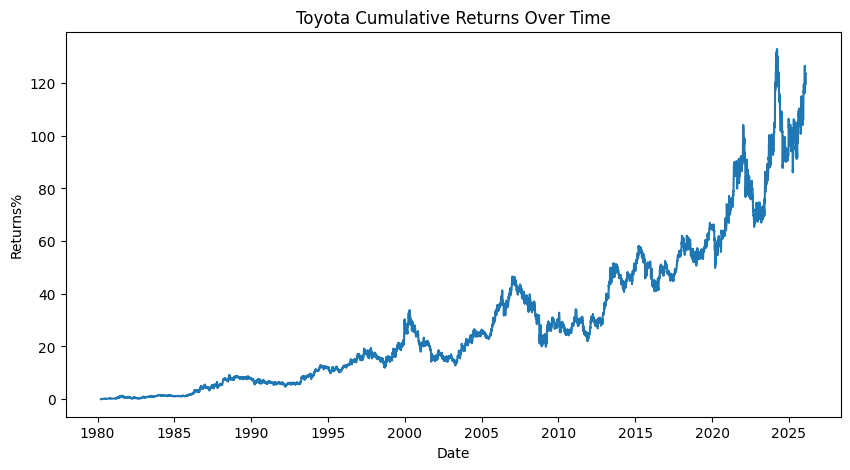

In [9]:
# Cumulative Returns Plot 
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['cumulative_return1'])
plt.title('Toyota Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns%')
plt.show()

### 📊 Cumulative Returns Insight

Toyota’s cumulative returns show a clear long-term upward trend, increasing from approximately **0% in 1980 to over 120% by 2025**, reflecting sustained value creation over time.

---

### 🔍 Key Observations

- **Long-term growth:**  
  The stock demonstrates steady appreciation, with cumulative returns gradually rising despite periods of volatility.

- **Cyclical drawdowns:**  
  Several significant declines are visible, highlighting exposure to macroeconomic shocks:
  - Early 2000s downturn, with returns falling from ~30% to ~15%  
  - **2008 financial crisis**, where returns dropped from ~45% to ~20%  
  - **2020 COVID-19 shock**, followed by a sharp recovery  

- **Strong recovery phases:**  
  Each downturn is followed by a rebound, indicating resilience and the ability to recover from market stress.

- **Recent acceleration (2020–2025):**  
  Returns increased from ~60% to over **120%**, showing strong momentum alongside increased volatility.

---

### 📈 Investment Interpretation

- Toyota exhibits characteristics of a **resilient, cyclical equity**, influenced by global economic conditions.
- The repeated pattern of decline and recovery suggests:
  - Sensitivity to macroeconomic shocks  
  - Strong long-term fundamentals  

- The presence of increasing volatility in recent years aligns with findings from the **GARCH model**, indicating persistent risk over time.

---

### 🎯 Key Takeaway

> Toyota delivers positive long-term returns with clear cyclical risk patterns, making it suitable for long-term investors who can tolerate periods of volatility.

## Daily Returns Analysis 

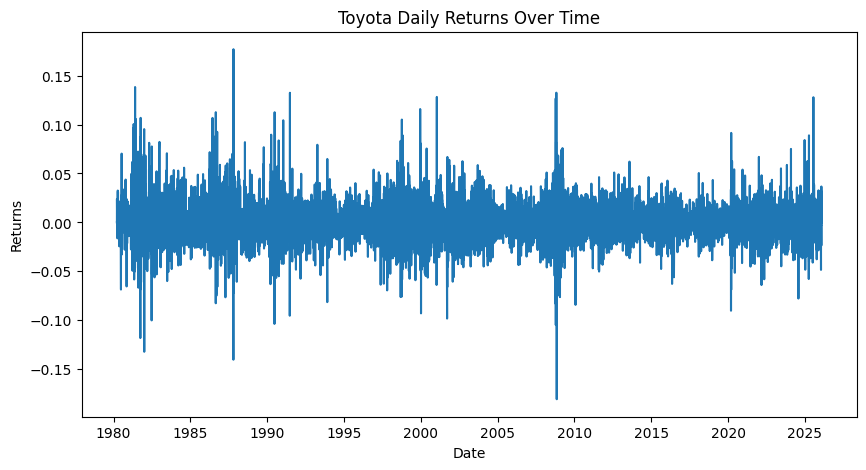

In [10]:
# Plot of returns over time 
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['log_return'])
plt.title('Toyota Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

### 📊 Daily Returns Insight

The daily returns of Toyota stock fluctuate around zero, showing no clear long-term trend in the mean but significant variation in volatility over time.

---

### 🔍 Key Observations

- **Mean-reverting behaviour:**  
  Returns are centred around **0**, indicating that daily price movements are largely unpredictable and consistent with the efficient market hypothesis.

- **Volatility clustering:**  
  Periods of high volatility are followed by further high volatility, while calmer periods persist over time.  
  This pattern is particularly visible:
  - Late 1980s  
  - Early 2000s  
  - Around the **2008 financial crisis**  
  - During the **2020 COVID-19 period**

- **Extreme movements (fat tails):**  
  The presence of large spikes (both positive and negative), with returns reaching approximately **±15%**, suggests that extreme market events occur more frequently than under a normal distribution.

- **Asymmetry in shocks:**  
  Some negative shocks appear more pronounced, indicating potential downside risk during market stress periods.

---

### 📈 Link to Volatility Modelling

- The observed **volatility clustering** strongly supports the use of a **GARCH model**.
- The presence of large spikes justifies modelling **time-varying volatility** rather than assuming constant variance.

---

### 🎯 Key Takeaway

> Toyota’s daily returns exhibit classic financial time series characteristics — mean reversion, volatility clustering, and extreme movements — making them well-suited for GARCH-based risk modelling.

### Key Insights

- Returns are centered around zero, indicating no strong trend in daily movements.
- Extreme values (fat tails) suggest higher probability of large losses.
- Volatility clustering is observed, where periods of high volatility are followed by similar periods.

## Volatility Analysis

Rolling volatility is computed to capture time-varying risk in the market.

Volatility represents the degree of fluctuation in returns and is a key measure of market risk.

In [11]:
#🔹 Daily Rolling Volatility
df['volatility'] = df['log_return'].rolling(window=30).std()

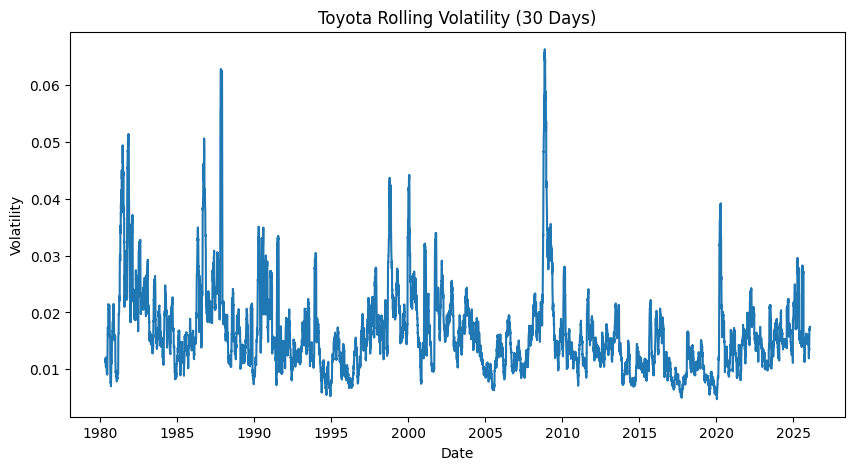

In [12]:
# Daily volatility plot
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['volatility'])
plt.title('Toyota Rolling Volatility (30 Days)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

### 📊 Rolling Volatility (30-Day) Insight

The 30-day rolling volatility of Toyota’s returns highlights significant fluctuations in risk over time, with clear periods of elevated and subdued market uncertainty.

---

### 🔍 Key Observations

- **Time-varying volatility:**  
  Volatility is not constant and varies considerably over time, confirming that financial markets experience changing levels of risk.

- **Volatility clustering:**  
  High-volatility periods tend to persist, followed by extended low-volatility periods.  
  This is particularly evident during:
  - Early 1980s and late 1980s  
  - Late 1990s to early 2000s  
  - **2008 financial crisis**, where volatility peaks above **6%**  
  - **2020 COVID-19 period**, showing a noticeable spike  

- **Extreme risk periods:**  
  The highest volatility occurs around **2008–2009**, indicating a period of severe market stress and uncertainty.

- **Calmer market phases:**  
  Periods such as **mid-1990s and mid-2010s** show relatively low volatility (around **1% or below**), reflecting more stable market conditions.

---

### 📈 Link to GARCH Model

- The presence of **volatility clustering** supports the use of a **GARCH model**.
- The persistence of volatility aligns with your findings where **α + β ≈ 0.99**, indicating that shocks to volatility decay slowly over time.

---

### 🎯 Key Takeaway

> Toyota’s volatility is highly dynamic, with prolonged periods of both high and low risk, reinforcing the importance of modelling time-varying volatility when assessing financial risk.

## Historical_Value at Risk (VaR)

Value at Risk (VaR) estimates the potential loss over a given time horizon at a specified confidence level.

We compute the 95% VaR using historical returns.

In [23]:
# Historical VaR
confidence_level = 0.95

Historical_VaR_95 = df['log_return_pct'].quantile(1 - confidence_level)

print(f"Historical_VaR (95%): {Historical_VaR_95:.3f}%")

Historical_VaR (95%): -2.677%


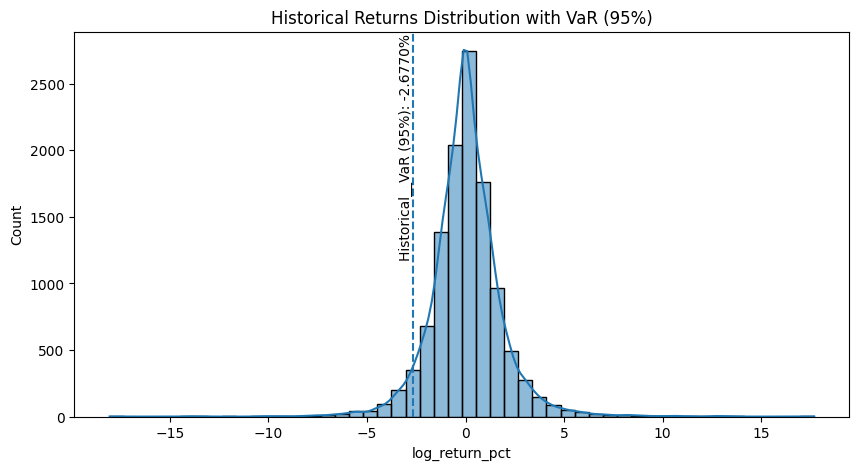

In [26]:
# Visualize VaR
plt.figure(figsize=(10,5))
sns.histplot(df['log_return_pct'], bins=50, kde=True)
plt.axvline(Historical_VaR_95, linestyle='--')
# ✅ Add label
plt.text(
    Historical_VaR_95,                     # x position
    plt.ylim()[1] * 0.7,        # y position (80% of height)
    f'Historical__VaR (95%): {Historical_VaR_95:.4f}%', # text
    rotation=90,
    verticalalignment='center',
    horizontalalignment='right'   # anchor text to the right (so it stays left of line)
)
plt.title('Historical Returns Distribution with VaR (95%)')
plt.show()

### 📊 Historical Returns Distribution & Value at Risk (VaR 95%)

The distribution of Toyota’s daily returns is centred around zero and exhibits a bell-shaped pattern, with noticeable fat tails indicating the presence of extreme market movements.

---

### 🔍 Key Observations

- **Distribution shape:**  
  The returns are approximately normally distributed around **0**, but with heavier tails than a standard normal distribution.

- **Fat tails (extreme events):**  
  The presence of large positive and negative returns suggests that extreme market movements occur more frequently than predicted by a normal distribution.

- **Left-tail risk:**  
  The downside tail is particularly important for risk management, as it captures potential losses during adverse market conditions.

---

### ⚠️ Value at Risk (VaR 95%)

- The **historical VaR at 95% confidence level is approximately -2.7%**.
- This means:
  
  > There is a 5% probability that daily losses will exceed **2.7%**.

---

### 📈 Risk Interpretation

- The VaR estimate highlights the **potential for significant short-term losses**, even in a generally stable market.
- Combined with earlier findings:
  - **Volatility clustering** (rolling volatility)  
  - **High persistence (GARCH model)**  

  → This suggests that risk is not constant and can increase significantly during turbulent periods.

---

### 🎯 Key Takeaway

> While Toyota’s returns are generally stable, the presence of fat tails and a VaR of -2.7% indicates that investors must be prepared for occasional but meaningful losses, particularly during periods of heightened volatility.

## GARCH Model

To model time-varying volatility, we use a GARCH(1,1) model.

This model captures:
- The impact of past shocks (alpha)
- The persistence of volatility (beta)

In [15]:
#pip install arch

In [16]:
# Fit a GARCH(1,1) Model
from arch import arch_model

model = arch_model(df['log_return_pct'], vol='Garch', p=1, q=1)
garch_fit = model.fit()

print(garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 78937.43423702527
Iteration:      2,   Func. Count:     15,   Neg. LLF: 83130.76373581856
Iteration:      3,   Func. Count:     24,   Neg. LLF: 2535249554.0652194
Iteration:      4,   Func. Count:     30,   Neg. LLF: 49226.5172473584
Iteration:      5,   Func. Count:     38,   Neg. LLF: 22000.96105906099
Iteration:      6,   Func. Count:     44,   Neg. LLF: 21993.10452232402
Iteration:      7,   Func. Count:     50,   Neg. LLF: 21914.889482320985
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3507421095.9387774
Iteration:      9,   Func. Count:     62,   Neg. LLF: 21920.030869571867
Iteration:     10,   Func. Count:     68,   Neg. LLF: 21902.49225942057
Iteration:     11,   Func. Count:     74,   Neg. LLF: 21902.05081160195
Iteration:     12,   Func. Count:     79,   Neg. LLF: 21902.050770629125
Iteration:     13,   Func. Count:     83,   Neg. LLF: 21902.05077063037
Optimization terminated successfully    (Exit mode 0)
      

### 📊 GARCH(1,1) Model Insight

The GARCH(1,1) model is used to capture the time-varying volatility of Toyota’s daily returns, providing insights into both return dynamics and risk persistence.

---

### 🔍 Mean Equation (Returns)

- The estimated mean return (**μ ≈ 0.0487**) is **positive and statistically significant** (p < 0.001).
- This indicates a small but consistent upward drift in daily returns.

> Interpreted in percentage terms, this corresponds to approximately **0.0487% per day**, which is consistent with long-term equity market performance.

---

### ⚡ Volatility Dynamics

- **ω (omega) = 0.0388**  
  Represents the baseline level of volatility.

- **α (alpha) = 0.0691**  
  Measures the impact of recent shocks (news) on volatility.

- **β (beta) = 0.9213**  
  Captures the persistence of volatility over time.

---

### 🔥 Volatility Persistence

- The sum of coefficients:
  
  **α + β ≈ 0.9904**

- This value is very close to 1, indicating **high volatility persistence**.

> This means that once volatility increases, it tends to remain elevated for a prolonged period.

---

### 📈 Model Interpretation

- The model confirms the presence of:
  - **Volatility clustering** (observed in rolling volatility)
  - **Time-varying risk**
- Financial markets do not exhibit constant variance, making GARCH an appropriate modelling choice.

---

### ⚠️ Risk Implications

- High persistence suggests that **market shocks have long-lasting effects**.
- Periods of instability (e.g., financial crises) can lead to **extended periods of elevated risk**.

---

### 🎯 Key Takeaway

> Toyota’s return series exhibits strong volatility clustering and persistence, making GARCH(1,1) an effective model for capturing its dynamic risk profile and supporting advanced risk measures such as Value at Risk (VaR).

## Historical Volatility & GARCH Conditional Volatility

### Insight

Volatility spikes during periods of market stress, confirming the presence of volatility clustering in financial markets.

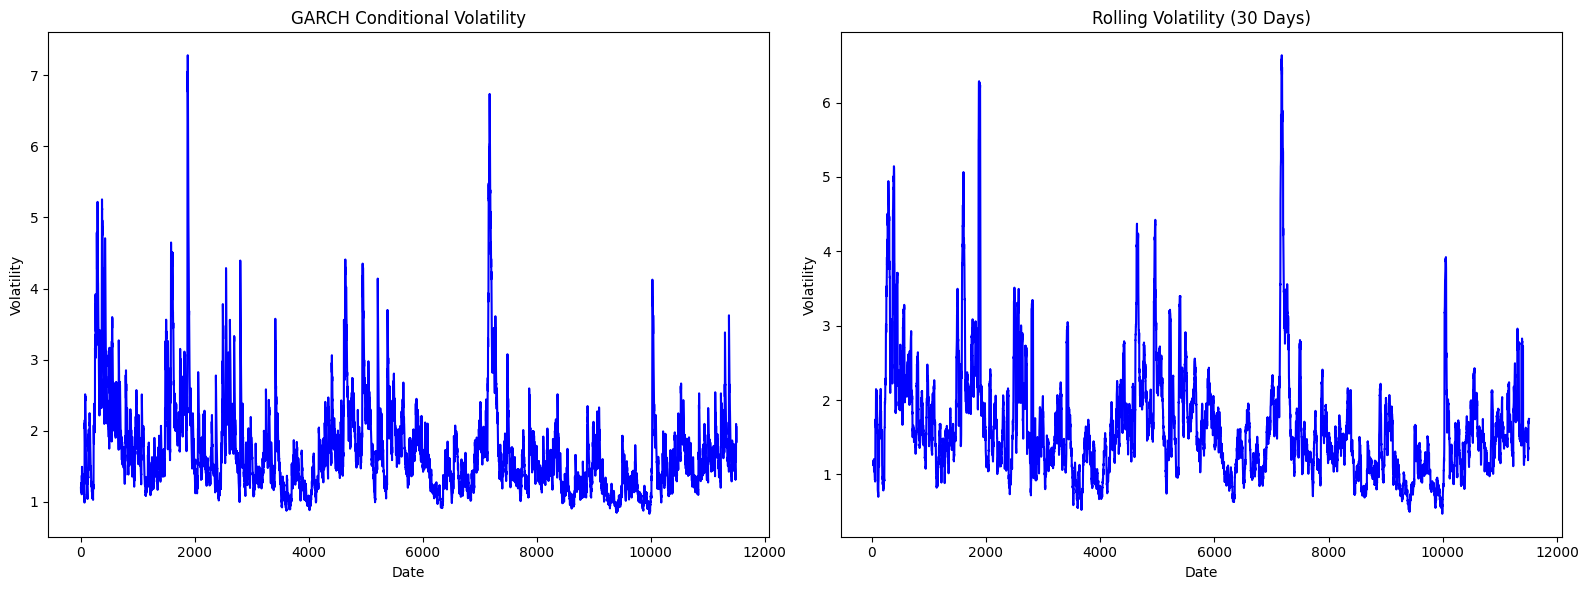

In [18]:
df['garch_vol']= garch_fit.conditional_volatility

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# Plot 1: GARCH Volatility
# -----------------------------
axes[0].plot(df.index, df['garch_vol'], color='blue')
axes[0].set_title('GARCH Conditional Volatility')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Volatility')

# -----------------------------
# Plot 2: Rolling Volatility
# -----------------------------
axes[1].plot(df.index, df['volatility']*100, color='blue')
axes[1].set_title('Rolling Volatility (30 Days)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### 📊 GARCH Conditional Volatility vs Rolling Volatility

This comparison highlights the difference between model-based volatility (GARCH) and historical rolling volatility (30-day), providing deeper insight into the dynamics of market risk.

---

### 🔍 Key Observations

- **Similar overall patterns:**  
  Both GARCH conditional volatility and rolling volatility exhibit similar trends over time, with clear spikes during periods of market stress.

- **Volatility clustering confirmed:**  
  Periods of high volatility (e.g., early 2000s, 2008 financial crisis, COVID-19 period) are consistently captured by both measures, reinforcing the presence of volatility clustering.

- **GARCH is smoother and forward-looking:**  
  - The GARCH volatility series appears **smoother**  
  - It reacts more gradually to shocks  
  - This reflects its ability to model **expected future volatility**, not just past observations  

- **Rolling volatility is more reactive:**  
  - Shows sharper and more immediate spikes  
  - Based purely on historical data within a fixed window (30 days)  
  - Can be more sensitive to short-term fluctuations  

---

### 📈 Model Interpretation

- The close alignment between the two measures validates the **GARCH(1,1) model** as an appropriate representation of volatility dynamics.
- GARCH captures the same risk patterns while providing a **more structured and predictive framework**.

---

### ⚠️ Risk Implications

- During periods of market stress, both measures increase significantly, indicating elevated risk.
- However, GARCH provides a more reliable estimate for:
  - **Forecasting volatility**
  - **Risk management applications (e.g., VaR)**

---

### 🎯 Key Takeaway

> While rolling volatility reflects historical risk, the GARCH model offers a more robust and forward-looking estimate of volatility, making it better suited for financial risk modelling and decision-making.

## GARCH based VaR

In [19]:
mu = garch_fit.params['mu']

# simulate returns
np.random.seed(42)
df['garch_simulated_return'] = mu + df['garch_vol'] * np.random.normal(size=len(df))
print(df['garch_simulated_return'].head())

1    0.643549
2   -0.112557
3    0.784934
4    1.981820
5   -0.241059
Name: garch_simulated_return, dtype: float64


In [21]:
# Computation of Garch VaR
confidence_level= 0.95
GARCH_VaR_95= df['garch_simulated_return'].quantile(1-confidence_level)
print(f"GARCH_VaR(95%) :{GARCH_VaR_95:.4f}%")

GARCH_VaR(95%) :-2.8072%


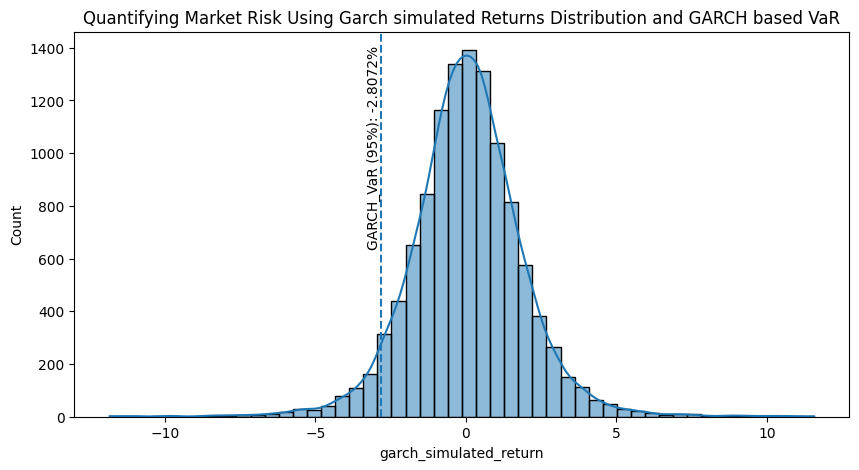

In [27]:
# Historical VaR plot 
plt.figure(figsize=(10,5))
sns.histplot(df['garch_simulated_return'], bins=50, kde=True)
plt.axvline(GARCH_VaR_95, linestyle='--')
# ✅ Add label
plt.text(
    GARCH_VaR_95,                     # x position
    plt.ylim()[1] * 0.7,        # y position (80% of height)
    f'GARCH_VaR (95%): {GARCH_VaR_95:.4f}%', # text
    rotation=90,
    verticalalignment='center',
    horizontalalignment='right'   # anchor text to the right (so it stays left of line)
)
plt.title('Quantifying Market Risk Using Garch simulated Returns Distribution and GARCH based VaR')
plt.show()

### 📊 Historical vs GARCH-Based Value at Risk (VaR 95%)

This section compares the historical distribution of returns with the GARCH-simulated distribution to evaluate differences in risk estimation.

---

### 🔍 Key Observations

- **Similar central distribution:**  
  Both historical and GARCH-simulated returns are centred around zero and exhibit a broadly similar bell-shaped distribution.

- **Fat tails in both approaches:**  
  Both distributions show evidence of extreme values, confirming that returns are not perfectly normally distributed.

- **Difference in dispersion:**  
  The GARCH-simulated distribution appears slightly wider, reflecting the model’s ability to incorporate time-varying volatility and periods of elevated risk.

---

### ⚠️ Value at Risk Comparison (95%)

- **Historical VaR (95%) ≈ -2.68%**  
- **GARCH VaR (95%) ≈ -2.81%**

---

### 📈 Interpretation of Differences

- The **GARCH-based VaR is more conservative** (larger potential loss).
- This occurs because GARCH accounts for:
  - **Volatility clustering**
  - **Persistence of shocks (α + β ≈ 0.99)**  
- In contrast, historical VaR assumes that past volatility is constant and may **underestimate risk during turbulent periods**.

---

### ⚠️ Risk Implications

- The difference between the two VaR estimates highlights that:
  - Risk is **dynamic**, not static  
  - Market conditions significantly influence potential losses  

- During periods of heightened volatility, relying solely on historical VaR may lead to **underestimation of downside risk**.

---

### 🎯 Key Takeaway

> While both methods provide similar baseline risk estimates, the GARCH-based VaR offers a more robust and forward-looking measure by incorporating volatility dynamics, making it better suited for real-world risk management.

## Final Conclusion

This analysis demonstrates that Toyota stock exhibits significant time-varying risk, characterised by volatility clustering and strong persistence.

The GARCH model reveals that volatility is primarily driven by its own past values, with shocks having a moderate but meaningful impact. The high persistence (α + β ≈ 0.99) indicates that periods of elevated risk tend to last over time.

From a risk management perspective, the estimated 95% Value at Risk of approximately -2.81% suggests that substantial daily losses are possible, particularly during volatile periods.

The comparison between historical and forecast VaR highlights that short-term risk is currently elevated, reinforcing the importance of dynamic risk assessment.

Overall, this project shows that relying on static measures of risk can underestimate market uncertainty, and that models like GARCH provide a more realistic and forward-looking view of financial risk.

## decision-oriented insight
This level of risk may require tighter risk controls, such as position sizing adjustments or hedging strategies during periods of elevated volatility.

For example:
- Dynamically reducing position sizes when volatility rises above historical norms (e.g., above 5%), limiting exposure to large price swings
- Hedging downside risk using derivatives such as put options or index futures to protect against adverse market movements
- Reallocating capital towards lower-volatility or defensive assets to stabilise portfolio risk
- Implementing stop-loss strategies to automatically exit positions during extreme downside scenarios

These actions help mitigate potential losses and ensure that portfolio risk remains aligned with the investor’s risk tolerance.